<a href="https://colab.research.google.com/github/ChrystianBellin/IC-V/blob/main/Rs(RW%E2%80%96CPE)_relat%C3%B3rio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

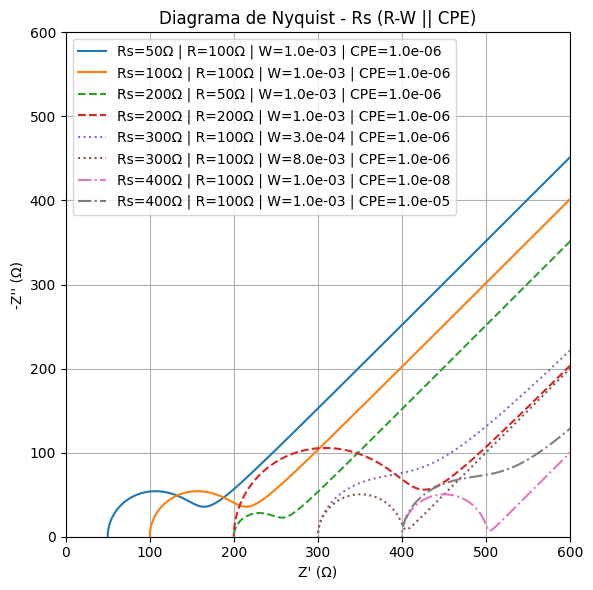

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Frequências
# =========================
frequencies = np.logspace(-2, 6, 1000)
omega = 2 * np.pi * frequencies

# =========================
# Funções dos elementos
# =========================

def Z_warburg(sigma, omega):
    return 1 / (sigma * np.sqrt(1j * omega))

def Z_cpe(Q, n, omega):
    return 1 / (Q * (1j * omega)**n)

def impedance_circuit(Rs, R, sigma, Q, n, omega):
    ZW = Z_warburg(sigma, omega)
    ZRW = R + ZW
    ZCPE = Z_cpe(Q, n, omega)

    Z_parallel = 1 / (1/ZRW + 1/ZCPE)
    Z_total = Rs + Z_parallel

    return Z_total.real, Z_total.imag

# =========================
# DEFINIÇÃO DAS CURVAS
# =========================
# Agora com estilo personalizável

curvas = [
    {"Rs": 50, "R": 100, "sigma": 1000e-6, "Q": 1e-6, "n": 1,
     "linestyle": "-", "marker": None},

    {"Rs": 100, "R": 100, "sigma": 1000e-6, "Q": 1e-6, "n": 1,
     "linestyle": "-", "marker": None},

    {"Rs": 200, "R": 50, "sigma": 1000e-6, "Q": 1e-6, "n": 1,
     "linestyle": "--", "marker": None},

    {"Rs": 200, "R": 200, "sigma": 1000e-6, "Q": 1e-6, "n": 1,
     "linestyle": "--", "marker": None},

    {"Rs": 300, "R": 100, "sigma": 3e-4, "Q": 1e-6, "n": 1,
     "linestyle": ":", "marker": None},

    {"Rs": 300, "R": 100, "sigma": 8e-3, "Q": 1e-6, "n": 1,
     "linestyle": ":", "marker": None},

    {"Rs": 400, "R": 100, "sigma": 1e-3, "Q": 1e-8, "n": 1,
     "linestyle": "-.", "marker": None},

    {"Rs": 400, "R": 100, "sigma": 1e-3, "Q": 1e-5, "n": 1,
     "linestyle": "-.", "marker": None},
]

# =========================
# Plot
# =========================
plt.figure(figsize=(8, 6))

for curva in curvas:
    Zr, Zi = impedance_circuit(
        curva["Rs"],
        curva["R"],
        curva["sigma"],
        curva["Q"],
        curva["n"],
        omega
    )

    label = (f"Rs={curva['Rs']}Ω | R={curva['R']}Ω | "
             f"W={curva['sigma']:.1e} | CPE={curva['Q']:.1e}")

    plt.plot(
        Zr,
        -Zi,
        linestyle=curva.get("linestyle", "-"),
        marker=curva.get("marker", None),
        markevery=50,  # evita excesso de pontos
        label=label
    )

# =========================
# Configurações
# =========================
plt.xlabel("Z' (Ω)")
plt.ylabel("-Z'' (Ω)")
plt.title("Diagrama de Nyquist - Rs (R-W || CPE)")
plt.legend(fontsize=10)
plt.grid(True)

# 🔹 deixa o gráfico quadrado
plt.gca().set_aspect('equal', adjustable='box')

plt.xlim(0, 600)
plt.ylim(0, 600)

plt.tight_layout()

# =========================
# SALVAR FIGURAS
# =========================
plt.savefig("nyquist Rs (RWCPE).png", dpi=300, bbox_inches='tight')
plt.savefig("nyquist Rs (RWCPE).eps", format='eps', bbox_inches='tight')

plt.show()
# TESTE CONTROLE VERSÃO